# Heart Disease Prediction Project
## 1. Data Loading
## 2. Data Cleaning
## 3. Exploratory Data Analysis




In [ ]:
# 1 Data Loading
import pandas as pd

columns = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"
]

df = pd.read_csv("/content/drive/MyDrive/Projects 2026/heart+disease/processed.cleveland.data", names=columns)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.replace("?", pd.NA, inplace=True)
df = df.dropna()
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    object 
 12  thal      297 non-null    object 
 13  target    297 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 34.8+ KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [ ]:
df["target"].value_counts()

,count
target,
0,160
1,137


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

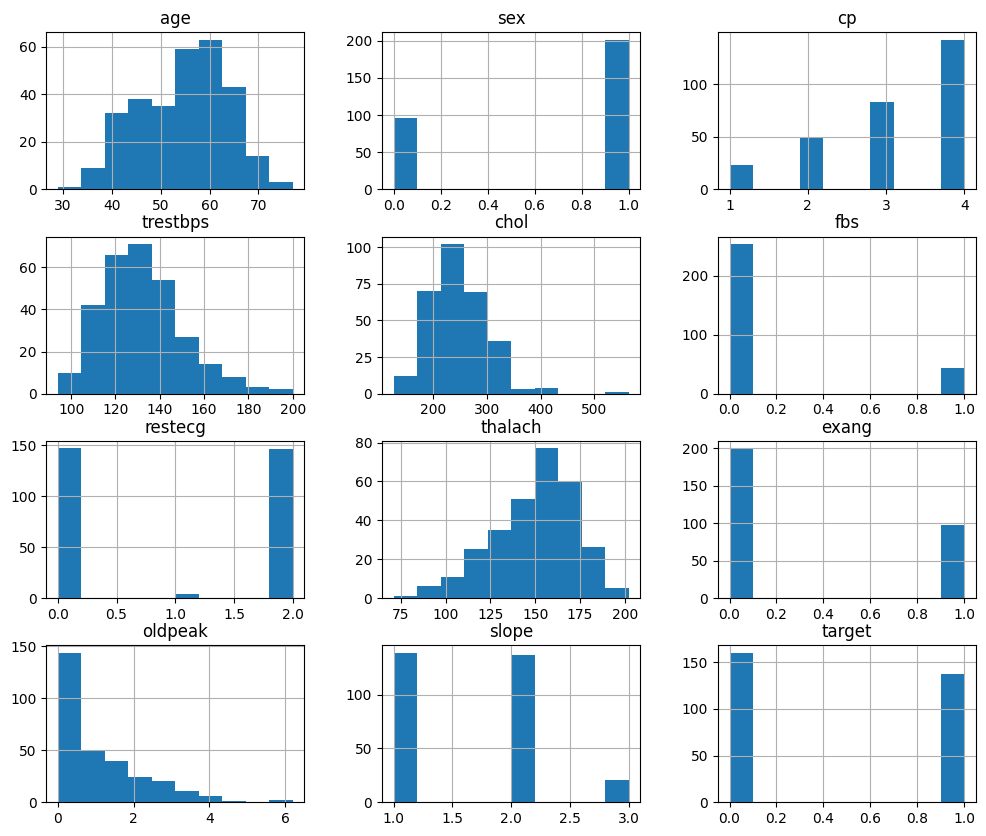

In [ ]:
df.hist(figsize=(12,10))
plt.show()

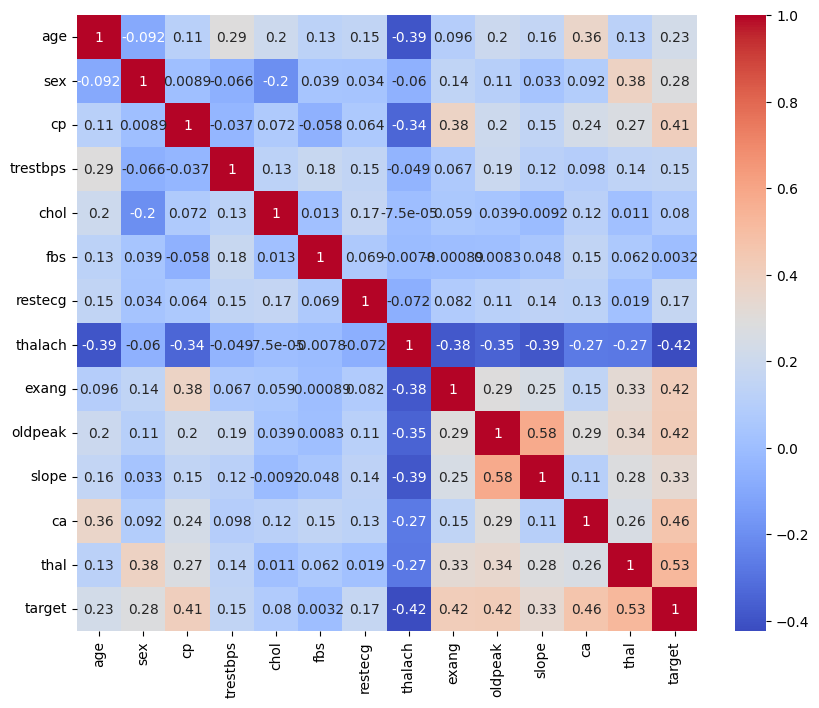

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# The strongest positive correlations with heart disease are thal (0.53), ca (0.46), and oldpeak (0.42), while thalach shows a strong negative correlation (-0.42). This suggests that these features are more influential predictors compared to others like cholesterol, which shows very weak correlation.

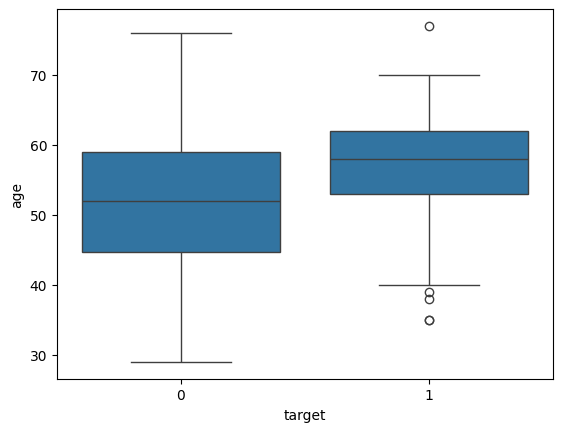

In [ ]:
sns.boxplot(x="target", y="age", data=df)
plt.show()

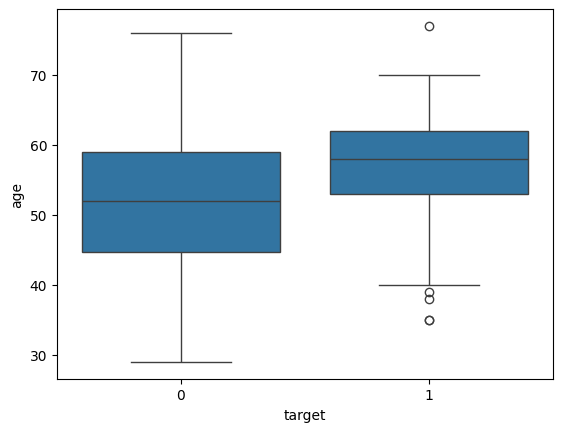

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="target", y="age", data=df)
plt.show()

 # Patients with heart disease tend to have a slightly higher median age, but there is significant overlap between the groups, indicating that age alone is not a strong predictor of heart disease.

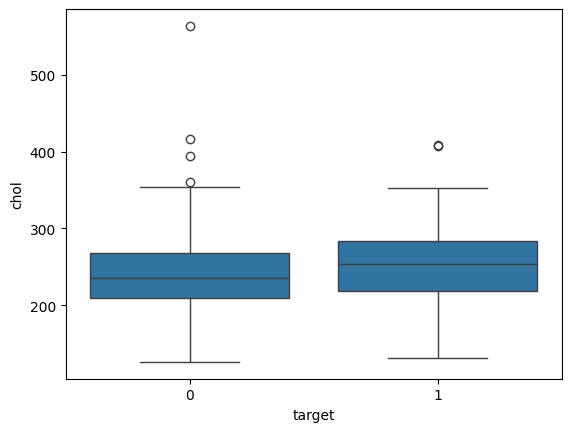

In [ ]:
sns.boxplot(x="target", y="chol", data=df)
plt.show()

# Cholesterol levels are slightly higher in individuals with heart disease; however, there is significant overlap between the two groups, suggesting that cholesterol alone is not a strong distinguishing feature.

## Exploratory Data Analysis (EDA) Insights

- Age shows slight relationship with heart disease but with significant overlap
- Cholesterol does not strongly differentiate between patients with and without heart disease
- Key features with strongest correlation to heart disease:
  - thal (0.53)
  - ca (0.46)
  - oldpeak (0.42)
- Maximum heart rate (thalach) shows a negative correlation (-0.42), suggesting higher values may be associated with lower risk

## 4. Model Building (Logistic Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Select features
X = df[["thal", "ca", "oldpeak", "exang", "cp", "thalach"]]
y = df["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9


In [ ]:
y.value_counts()

,count
target,
0,160
1,137


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        36
           1       0.88      0.88      0.88        24

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



## Model Results

- Built a Logistic Regression model using selected features
- Evaluated model performance using accuracy score
- Achieved an accuracy of 0.9

# 5. Model Comparison (Decision Tree)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluate
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy * 100, "%")

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 75.0 %
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        36
           1       0.67      0.75      0.71        24

    accuracy                           0.75        60
   macro avg       0.74      0.75      0.74        60
weighted avg       0.76      0.75      0.75        60



## Decision Tree Results

- Built a Decision Tree model for comparison
- Compared performance with Logistic Regression
- Observed accuracy of 75%
- Evaluated precision and recall for both classes
- Noted differences in model behavior

## Model Comparison Insight

- Logistic Regression outperformed Decision Tree (90% vs 75%)
- Decision Tree likely overfitted the training data
- Simpler models can perform better on structured datasets
- Model complexity does not guarantee better performance

## Tried to improve Decision Tree Accuracy below.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Limit depth to reduce overfitting
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Improved Decision Tree Accuracy:", accuracy_score(y_test, dt_pred) * 100, "%")

Improved Decision Tree Accuracy: 80.0 %


## Model Improvement Insight

- Tuned Decision Tree by limiting max_depth to reduce overfitting
- Accuracy improved from 75% to 80%
- Demonstrates impact of controlling model complexity
- Logistic Regression (90%) still outperforms Decision Tree

## 6. Advanced Model (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy * 100, "%")

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 86.66666666666667 %
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



## 7. Model Evaluation (Confusion Matrix & ROC Curve)

## CONFUSION MATRIX

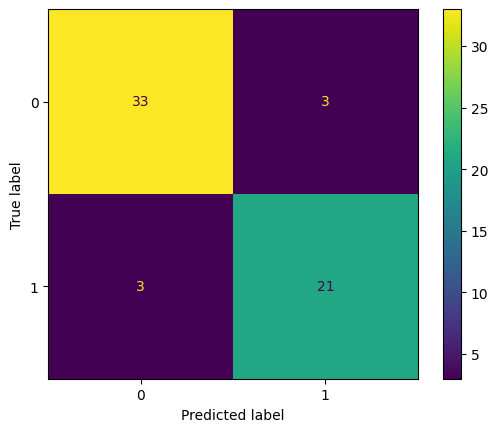

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## ROC CURVE

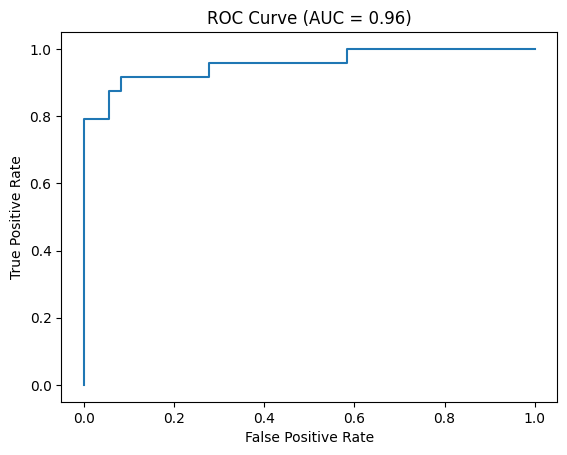

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()

## Final Evaluation Insight

- Model achieved strong performance with high accuracy and AUC (0.96)
- Only 3 false negatives, indicating strong recall for detecting heart disease
- Demonstrates ability to correctly identify most positive cases
- Shows importance of evaluating beyond accuracy using confusion matrix and ROC

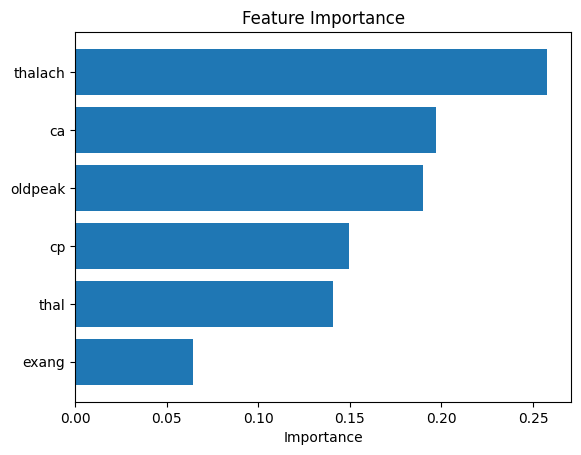

,Feature,Importance
5,thalach,0.257919
1,ca,0.197181
2,oldpeak,0.190082
4,cp,0.149293
0,thal,0.140954
3,exang,0.064571


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
importances = rf_model.feature_importances_
features = X.columns

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

feat_imp

## 8. Extracted feature importance using Random Forest
- Top features: thalach, ca, oldpeak
- Observed that model prioritizes cardiovascular stress indicators and vessel blockage
- Findings align with known clinical risk factors for heart disease
- Improved interpretability and trust in model predictions